# K-Means Clustering

I'm going to try clustering several different variations of the data: the differences data, the unordered differences, and the ratio $t_{bike}$ to $t_{drive}$

In [21]:
import load_data as ld

import matplotlib.pyplot as plt
import sklearn.cluster as cluster

In [22]:
diff_df = ld.load_comparison_data("./data/modality_deltas")
diff_df.head()

,home->downtown,home->nature,home->nearby city,local icon->home,local icon->downtown,local icon->nature,local icon->nearby city,grocery->home,grocery->downtown,grocery->nature,grocery->nearby city,hospital->home,hospital->downtown,hospital->nature,hospital->nearby city,stadium->home,stadium->downtown,stadium->nature,stadium->nearby city
city,,,,,,,,,,,,,,,,,,,
Akron,160,3645,9651,574,1131,2760,10408,71,263,3856,9708,275,151,3609,9990,445,-32,3887,6117
Alamosa,38,8662,32963,7612,7539,0,21773,133,91,8305,32606,25,10,8607,32908,193,151,8318,32619
Albany,72,22,3780,160,51,282,3903,130,211,119,4259,-5,59,-5,3726,331,61,469,4097
Albuquerque,408,3302,3294,1171,93,4619,2603,-1,406,3262,3239,100,245,3652,3198,440,316,4356,3649
Allentown,402,531,2251,651,196,553,1414,537,949,856,3280,203,296,368,2428,1373,635,997,855


In [25]:
ratio_df = ld.load_comparison_data("./data/bike_over_drive")
ratio_df.dropna(inplace=True)

unlabeled_diff_df = diff_df.copy()
# sort each row by value
unlabeled_diff_df = unlabeled_diff_df.apply(lambda x: sorted(x), axis=1, result_type="expand")
unlabeled_diff_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
city,,,,,,,,,,,,,,,,,,,
Akron,-32,71,151,160,263,275,445,574,1131,2760,3609,3645,3856,3887,6117,9651,9708,9990,10408
Alamosa,0,10,25,38,91,133,151,193,7539,7612,8305,8318,8607,8662,21773,32606,32619,32908,32963
Albany,-5,-5,22,51,59,61,72,119,130,160,211,282,331,469,3726,3780,3903,4097,4259
Albuquerque,-1,93,100,245,316,406,408,440,1171,2603,3198,3239,3262,3294,3302,3649,3652,4356,4619
Allentown,196,203,296,368,402,531,537,553,635,651,855,856,949,997,1373,1414,2251,2428,3280


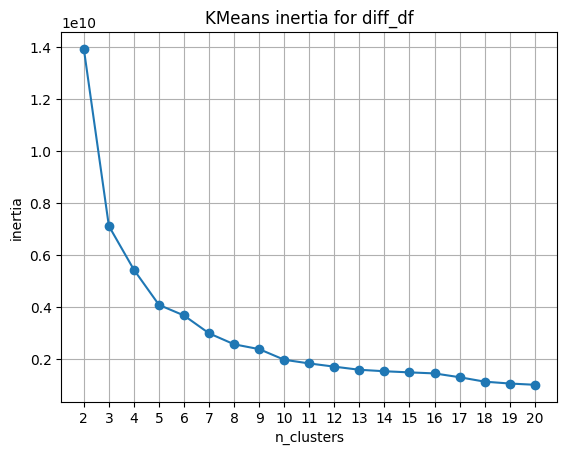

(array([1, 2, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 2, 2, 1, 0, 0, 0, 2, 1, 0,
        1, 0, 2, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 1, 0,
        1, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 2, 0, 1, 0,
        0, 0, 0, 1, 0, 1, 0, 0, 2, 1, 2, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0], dtype=int32),
 7129409976.469698)

In [ ]:
def kmeans_cluster(df, n_clusters):
    km = cluster.KMeans(n_clusters=n_clusters, random_state=0)
    km.fit(df)
    return km.labels_, km.inertia_

# plot kmeans clustering inertias for 2-20 clusters

ks = range(2, 21)
diff_inertias = [kmeans_cluster(diff_df, k)[1] for k in ks]

plt.plot(ks, diff_inertias, marker='o')
plt.xticks(ks)
plt.xlabel('n_clusters')
plt.ylabel('inertia')
plt.title('KMeans inertia for diff_df')
plt.grid(True)
plt.show()


It looks like a good number of clusters to use is 5. 7 clusters has Alamosa all alone.

In [19]:
diff_labels, diff_inertia = kmeans_cluster(diff_df, 5)

# print cities in each cluster
for i in range(5):
    print(f"Cluster {i}:")
    print(diff_df.index[diff_labels == i].tolist())
    print()

Cluster 0:
['Albany', 'Albuquerque', 'Allentown', 'Anaheim', 'Ann_Arbor', 'Atlantic_City', 'Austin', 'Baltimore', 'Bend', 'Boise', 'Boulder', 'Burlington', 'Carlsbad', 'Corvallis', 'Davis', 'Denver', 'Destin', 'Duluth', 'Eugene', 'Fairbanks', 'Fargo', 'Fayetteville', 'Fort_Collins', 'Hartford', 'Hayward', 'Indianapolis', 'Jacksonville', 'Kenosha', 'Lansing', 'Lexington', 'Madison', 'Midland', 'Minneapolis', 'Omaha', 'Phoenix', 'Portland', 'Providence', 'Reno', 'Salt_Lake_City', 'Santa_Barbara', 'Sarasota', 'Spokane', 'St._George', 'St._Louis', 'Syracuse', 'Tacoma', 'Traverse_City', 'Tucson', 'Tulsa', 'Westchester', 'Wilmington']

Cluster 1:
['Asheville', 'Bellingham', 'Branson', 'Charleston', 'Charlottesville', 'Columbia', 'Dover', 'Forks', 'Fort_Wayne', 'Hattiesburg', 'Keene', 'Mesquite', 'Pocatello', 'Rolla', 'Salina', 'Wichita']

Cluster 2:
['Alamosa', 'Baton_Rouge', 'Bozeman', 'Casper', 'Flagstaff', 'Jackson', 'Lubbock', 'Punxsutawney']

Cluster 3:
['Akron', 'Altoona', 'Bakersfield

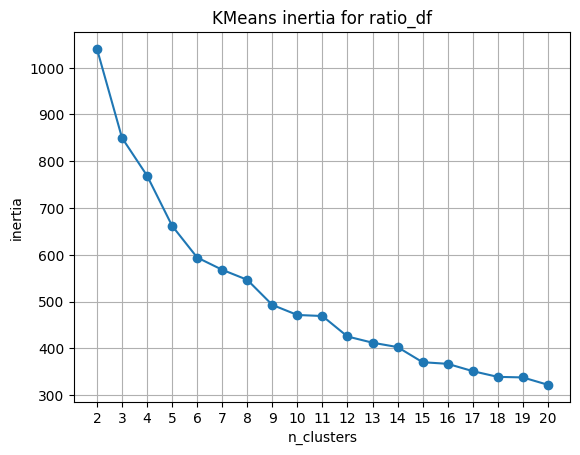

In [26]:
ratio_inertias = [kmeans_cluster(ratio_df, k)[1] for k in ks]

plt.plot(ks, ratio_inertias, marker='o')
plt.xticks(ks)
plt.xlabel('n_clusters')
plt.ylabel('inertia')
plt.title('KMeans inertia for ratio_df')
plt.grid(True)
plt.show()

Looks like we want either 6 or 9 clusters

In [37]:
ratio_labels, ratio_inertia = kmeans_cluster(ratio_df, 6)

# print cities in each cluster
for i in range(6):
    print(f"Cluster {i}:")
    print(ratio_df.index[ratio_labels == i].tolist())
    print()

Cluster 0:
['Albany', 'Allentown', 'Ann_Arbor', 'Baltimore', 'Boise', 'Burlington', 'Corvallis', 'Denver', 'Destin', 'Eugene', 'Fairbanks', 'Fargo', 'Hartford', 'Hayward', 'Midland', 'Portland', 'Providence', 'Reno', 'Salt_Lake_City', 'Sarasota', 'St._Louis', 'Tacoma', 'Tucson', 'Westchester', 'Wilmington', 'Worcester']

Cluster 1:
['Albuquerque', 'Anaheim', 'Atlantic_City', 'Bend', 'Boulder', 'Carbondale', 'Duluth', 'Fayetteville', 'Fort_Collins', 'Fort_Wayne', 'Indianapolis', 'Ironton', 'Jacksonville', 'Lexington', 'Madison', 'Minneapolis', 'Omaha', 'Syracuse']

Cluster 2:
['Akron', 'Bakersfield', 'Bangor', 'Bellingham', 'Casper', 'Charleston', 'Charlottesville', 'Chattanooga', 'Columbia', 'Dover', 'Forks', 'Hattiesburg', 'Huntsville', 'Johnson_City', 'Mesquite', 'Norfolk', 'Peoria', 'Rolla', 'San_Luis_Obispo', 'Wichita']

Cluster 3:
['Flagstaff', 'Keene', 'St._George', 'Tulsa']

Cluster 4:
['Baton_Rouge', 'Rapid_City', 'Raton']

Cluster 5:
['Asheville', 'Austin', 'Bozeman', 'Cedar_R

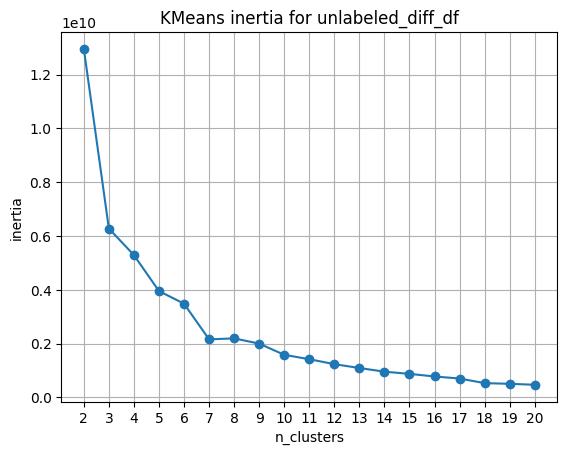

In [32]:
unlabeled_diff_df_inertias = [kmeans_cluster(unlabeled_diff_df, k)[1] for k in ks]

plt.plot(ks, unlabeled_diff_df_inertias, marker='o')
plt.xticks(ks)
plt.xlabel('n_clusters')
plt.ylabel('inertia')
plt.title('KMeans inertia for unlabeled_diff_df')
plt.grid(True)
plt.show()

It looks like either 5 or 7 is our elbow

In [38]:
unlabeled_diff_df_labels, unlabeled_diff_df_inertia = kmeans_cluster(unlabeled_diff_df, 5)

# print cities in each cluster
for i in range(5):
    print(f"Cluster {i}:")
    print(unlabeled_diff_df.index[unlabeled_diff_df_labels == i].tolist())
    print()

Cluster 0:
['Albany', 'Albuquerque', 'Allentown', 'Anaheim', 'Ann_Arbor', 'Atlantic_City', 'Austin', 'Baltimore', 'Bend', 'Boise', 'Boulder', 'Burlington', 'Carlsbad', 'Corvallis', 'Dallas', 'Davis', 'Denver', 'Destin', 'Duluth', 'Eugene', 'Fairbanks', 'Fargo', 'Fayetteville', 'Fort_Collins', 'Hartford', 'Hayward', 'Indianapolis', 'Ironton', 'Jacksonville', 'Kenosha', 'Lansing', 'Lexington', 'Madison', 'Midland', 'Minneapolis', 'Omaha', 'Phoenix', 'Portland', 'Providence', 'Reno', 'Salt_Lake_City', 'Santa_Barbara', 'Santa_Cruz', 'Sarasota', 'Spokane', 'St._George', 'St._Louis', 'Syracuse', 'Tacoma', 'Tucson', 'Tulsa', 'Westchester', 'Wilmington', 'Worcester']

Cluster 1:
['Charlottesville', 'Columbia', 'Flagstaff', 'Forks', 'Hattiesburg', 'Keene', 'Rolla']

Cluster 2:
['Alamosa', 'Bangor', 'Baton_Rouge', 'Bozeman', 'Casper', 'Grand_Junction', 'Jackson', 'Lubbock', 'Punxsutawney', 'Raton']

Cluster 3:
['Asheville', 'Bellingham', 'Branson', 'Charleston', 'Fort_Wayne', 'Mesquite', 'Pocate